# 🏗️ Autodesk Inside Sales — Lead Classifier
### Fine-tuning an LLM (LoRA/QLoRA) on Text + Tabular Data

**Goal:** Classify Autodesk leads into one of 5 tiers:
- `student` → Academic/student license seekers
- `low_interest` → Casual browsers, unlikely to convert
- `high_interest` → Actively evaluating, strong engagement
- `high_value` → Decision makers, budget-ready
- `diamond` → Enterprise whales, top-tier accounts

**Approach:** Serialize tabular (Marketo + product) data into text → fine-tune LLM with LoRA  
**Strategy:** Weighted sampling + class-weighted loss to handle class imbalance

---
### 📋 Notebook Sections
1. Install & Imports
2. Synthetic Data Generation
3. Data Preprocessing & Serialization
4. Class Imbalance Analysis
5. Dataset Preparation (Weighted Sampling)
6. Model Setup (LoRA/QLoRA)
7. Training with Class-Weighted Loss
8. Evaluation
9. Inference on New Incoming Leads
---

## 1. 📦 Install Dependencies

We use:
- `transformers` — Hugging Face model & tokenizer
- `peft` — LoRA adapter fine-tuning (lightweight, memory-efficient)
- `bitsandbytes` — 4-bit quantization (QLoRA, runs on 1 GPU)
- `datasets` — Hugging Face dataset utilities
- `scikit-learn` — Metrics and train/test split
- `pandas`, `numpy` — Data wrangling
- `matplotlib`, `seaborn` — Visualization

In [1]:
# ─── Install all required packages ───────────────────────────────────────────
# Run this cell once. Restart kernel after installation if needed.

!pip install -q transformers peft bitsandbytes datasets accelerate
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm

## 2. 📥 Imports & Configuration

In [2]:
# ─── Standard Library ─────────────────────────────────────────────────────────
import random
import warnings
warnings.filterwarnings('ignore')

# ─── Data Wrangling ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── ML Utilities ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ─── Hugging Face ─────────────────────────────────────────────────────────────
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training
)
from datasets import Dataset as HFDataset

# ─── Global Config ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Label definitions (ordered by tier, lowest to highest)
LABELS = ['student', 'low_interest', 'high_interest', 'high_value', 'diamond']
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

print("✅ Imports complete")
print(f"📊 Classes: {LABELS}")
print(f"🖥️  CUDA available: {torch.cuda.is_available()}")

✅ Imports complete
📊 Classes: ['student', 'low_interest', 'high_interest', 'high_value', 'diamond']
🖥️  CUDA available: False


## 3. 🧪 Synthetic Data Generation

We simulate realistic Autodesk inside sales leads with:
- **Text fields:** Sales notes, chat transcripts, email summaries
- **Marketo fields:** Email opens, clicks, form fills, webinar attendance
- **Product interest fields:** Which Autodesk products they've shown interest in
- **Firmographic fields:** Company size, industry, role

> ⚠️ **Label leakage reminder:** In real data, make sure the labels were NOT derived
> from the same features you feed in. Otherwise the model learns a trivial rule, not
> genuine lead intelligence.

In [3]:
# ─── Synthetic Data Generator ─────────────────────────────────────────────────
# Each class has realistic profiles that differ in engagement, intent, and firmographics

# Autodesk product lines
PRODUCTS = [
    'AutoCAD', 'Revit', 'Fusion 360', 'Civil 3D', 'Inventor',
    'Navisworks', '3ds Max', 'Maya', 'BIM 360', 'Vault'
]

INDUSTRIES = [
    'Architecture', 'Engineering', 'Construction', 'Manufacturing',
    'Media & Entertainment', 'Education', 'Aerospace', 'Automotive'
]

ROLES = [
    'Student', 'Freelancer', 'Designer', 'Engineer', 'Architect',
    'BIM Manager', 'IT Manager', 'VP Engineering', 'CTO', 'Procurement Manager'
]

COMPANY_SIZES = ['1-10', '11-50', '51-200', '201-500', '501-1000', '1000+']


# ─── Text templates per class (simulating real sales notes) ───────────────────
TEXT_TEMPLATES = {
    'student': [
        "Student at {uni} studying {field}. Looking for educational license for AutoCAD. "
        "Mentioned they need it for a semester project. No budget, wants free access.",
        "Reached out via chat asking about student discounts. Currently in year {year} of "
        "their degree. Interested in Fusion 360 for coursework only.",
        "University student looking to learn {product} for academic purposes. "
        "No professional need mentioned. Directed to Education plan.",
    ],
    'low_interest': [
        "Downloaded a whitepaper but hasn't responded to follow-up emails. "
        "Visited pricing page once. No demo scheduled.",
        "Attended a free webinar 3 months ago. Cold on follow-up. "
        "Mentioned they're 'just exploring options' for next year.",
        "Casual inquiry about {product}. Small team, no immediate project. "
        "Said they'll revisit in Q4. Low urgency signals throughout.",
    ],
    'high_interest': [
        "Actively evaluating {product} vs competitors. Attended 2 webinars, "
        "requested a demo. Team of {size} engineers. Decision expected in 6 weeks.",
        "Strong engagement — opened 8 emails, clicked product comparison docs. "
        "Asked detailed questions about {product} API integration. Budget exists.",
        "In active evaluation phase. Filled out ROI calculator, downloaded case studies. "
        "Spoke with technical team. Shortlisting vendors now.",
    ],
    'high_value': [
        "VP of Engineering at {company}. Budget approved for {product} rollout across "
        "{size} seats. Wants enterprise agreement. Decision in 2 weeks.",
        "Director-level contact, {industry} firm with {emp} employees. "
        "Replacing legacy CAD stack. Signed NDA, in final negotiations.",
        "Procurement lead at {company}. Formal RFQ submitted for {product}. "
        "IT security review underway. High close probability.",
    ],
    'diamond': [
        "Global {industry} enterprise with {emp}+ employees. "
        "Seeking multi-year EBA for full Autodesk suite. CTO involved. "
        "ACV potential $500K+. Executive sponsor engaged.",
        "Fortune 500 {industry} company. Standardizing on Autodesk BIM stack globally. "
        "Multi-region deployment, {emp} seats. Contract being reviewed by legal.",
        "Strategic account. CIO and VP Eng both on calls. {product} + BIM 360 bundle. "
        "$1M+ ACV. Exec alignment achieved. Closing this quarter.",
    ]
}


def generate_lead(label: str) -> dict:
    """
    Generate one synthetic Autodesk lead with text notes + Marketo + product data.
    Each class has distinct engagement and firmographic profiles.
    """

    # ── Marketo engagement signals (scale with lead quality) ─────────────────
    engagement_profiles = {
        'student':       dict(email_opens=(0,3),  clicks=(0,2),  form_fills=(0,1),  webinars=(0,1),  site_visits=(1,5)),
        'low_interest':  dict(email_opens=(0,5),  clicks=(0,3),  form_fills=(0,2),  webinars=(0,2),  site_visits=(1,8)),
        'high_interest': dict(email_opens=(5,20), clicks=(3,12), form_fills=(2,6),  webinars=(1,4),  site_visits=(5,25)),
        'high_value':    dict(email_opens=(10,30),clicks=(8,20), form_fills=(4,10), webinars=(2,5),  site_visits=(10,40)),
        'diamond':       dict(email_opens=(15,40),clicks=(10,30),form_fills=(5,15), webinars=(3,7),  site_visits=(20,60)),
    }

    # ── Company/firmographic profiles ────────────────────────────────────────
    firmographic_profiles = {
        'student':       dict(sizes=['1-10'],            roles=['Student']),
        'low_interest':  dict(sizes=['1-10','11-50'],    roles=['Freelancer','Designer','Engineer']),
        'high_interest': dict(sizes=['11-50','51-200'],  roles=['Engineer','Architect','BIM Manager']),
        'high_value':    dict(sizes=['51-200','201-500'],roles=['BIM Manager','IT Manager','VP Engineering']),
        'diamond':       dict(sizes=['501-1000','1000+'],roles=['VP Engineering','CTO','Procurement Manager']),
    }

    # ── Num products interested in (more = higher intent) ────────────────────
    product_count = {'student':1, 'low_interest':1, 'high_interest':2, 'high_value':3, 'diamond':4}

    ep = engagement_profiles[label]
    fp = firmographic_profiles[label]

    product = random.choice(PRODUCTS)
    industry = random.choice(INDUSTRIES)
    company  = f"{random.choice(['Apex','Nova','Global','Summit','Peak'])} {industry[:4]}works"
    emp      = random.choice([50, 200, 500, 2000, 10000])
    size     = random.randint(2, 50)
    year     = random.randint(1, 4)
    uni      = random.choice(['MIT', 'Stanford', 'Georgia Tech', 'Purdue', 'TU Delft'])
    field    = random.choice(['Civil Engineering', 'Architecture', 'Mechanical Eng', 'Product Design'])

    # ── Generate text note from template ─────────────────────────────────────
    template = random.choice(TEXT_TEMPLATES[label])
    text_note = template.format(
        product=product, company=company, industry=industry,
        emp=emp, size=size, year=year, uni=uni, field=field
    )

    return {
        # ── Text ──────────────────────────────────────────────────────────────
        'sales_notes': text_note,

        # ── Marketo engagement ────────────────────────────────────────────────
        'email_opens':   random.randint(*ep['email_opens']),
        'email_clicks':  random.randint(*ep['clicks']),
        'form_fills':    random.randint(*ep['form_fills']),
        'webinars_attended': random.randint(*ep['webinars']),
        'site_visits':   random.randint(*ep['site_visits']),

        # ── Product interest ──────────────────────────────────────────────────
        'products_interested': ', '.join(random.sample(PRODUCTS, product_count[label])),
        'primary_product': product,
        'requested_demo': 1 if label in ['high_interest','high_value','diamond'] and random.random()>0.3 else 0,
        'trial_started':  1 if label in ['high_interest','high_value','diamond'] and random.random()>0.5 else 0,

        # ── Firmographic ──────────────────────────────────────────────────────
        'industry': industry,
        'company_size': random.choice(fp['sizes']),
        'contact_role': random.choice(fp['roles']),

        # ── Label ─────────────────────────────────────────────────────────────
        'label': label
    }


# ── Simulate realistic class imbalance (as seen in real inside sales data) ────
CLASS_COUNTS = {
    'student':       1600,
    'low_interest':  1400,
    'high_interest':  700,
    'high_value':     250,
    'diamond':         50
}
TOTAL = sum(CLASS_COUNTS.values())   # 4000 leads

all_leads = []
for label, count in CLASS_COUNTS.items():
    all_leads.extend([generate_lead(label) for _ in range(count)])

random.shuffle(all_leads)  # Shuffle so classes aren't in order

df = pd.DataFrame(all_leads)
print(f"✅ Generated {len(df)} leads")
print(f"\n📊 Class Distribution:")
print(df['label'].value_counts())
df.head(3)

✅ Generated 4000 leads

📊 Class Distribution:
label
student          1600
low_interest     1400
high_interest     700
high_value        250
diamond            50
Name: count, dtype: int64


,sales_notes,email_opens,email_clicks,form_fills,webinars_attended,site_visits,products_interested,primary_product,requested_demo,trial_started,industry,company_size,contact_role,label
0,Actively evaluating Revit vs competitors. Atte...,14,9,2,2,11,"Navisworks, Inventor",Revit,1,1,Manufacturing,11-50,Architect,high_interest
1,Downloaded a whitepaper but hasn't responded t...,5,1,2,1,6,Fusion 360,Revit,0,0,Architecture,1-10,Designer,low_interest
2,"Casual inquiry about Navisworks. Small team, n...",2,0,2,2,5,Vault,Navisworks,0,0,Manufacturing,11-50,Freelancer,low_interest


## 4. 📊 Visualize Class Imbalance

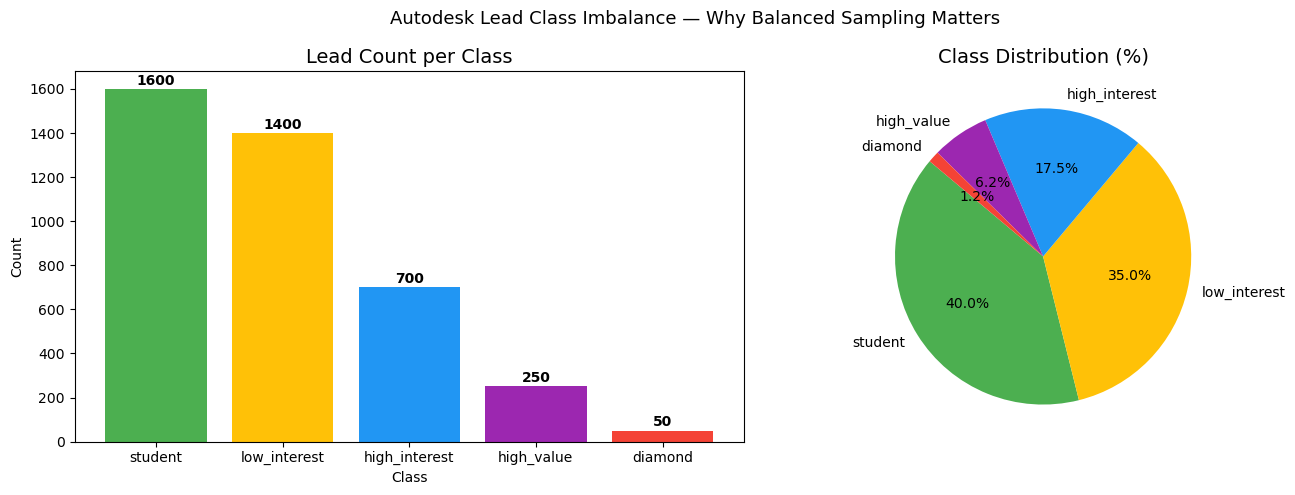


💡 Notice: 'diamond' is only ~1.25% of data.
   Without balancing, the model will almost never predict 'diamond' correctly.


In [4]:
# ─── Plot class distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts().reindex(LABELS)
colors = ['#4CAF50', '#FFC107', '#2196F3', '#9C27B0', '#F44336']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Lead Count per Class', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=14)

plt.suptitle('Autodesk Lead Class Imbalance — Why Balanced Sampling Matters', fontsize=13)
plt.tight_layout()
plt.show()

print("\n💡 Notice: 'diamond' is only ~1.25% of data.")
print("   Without balancing, the model will almost never predict 'diamond' correctly.")

## 5. 🔤 Text Serialization — Combining Text + Tabular

**Key idea:** We convert ALL features (text + tabular) into a single natural language string.
This is what gets fed into the LLM. Internally, the LLM's attention mechanism learns which
parts of this serialized input matter most for each class — *that's* where embeddings happen.

Example output:
```
[LEAD PROFILE]
Sales Notes: VP of Engineering at Apex Archworks. Budget approved...
Marketo Engagement: email_opens=22, clicks=14, forms=6, webinars=3, site_visits=35
Products Interested: Revit, BIM 360, Navisworks
Demo Requested: Yes | Trial Started: Yes
Company: Industry=Architecture, Size=201-500, Role=VP Engineering
[CLASSIFY]
```

In [5]:
def serialize_lead(row: pd.Series) -> str:
    """
    Convert a lead row (text + tabular) into a single structured text string.
    
    This is the core of Approach #1: we don't need separate embedding pipelines.
    The LLM reads everything as natural language and learns the patterns.
    """
    return (
        f"[LEAD PROFILE]\n"
        f"Sales Notes: {row['sales_notes']}\n"
        f"Marketo Engagement: "
        f"email_opens={row['email_opens']}, "
        f"email_clicks={row['email_clicks']}, "
        f"form_fills={row['form_fills']}, "
        f"webinars_attended={row['webinars_attended']}, "
        f"site_visits={row['site_visits']}\n"
        f"Products Interested: {row['products_interested']}\n"
        f"Demo Requested: {'Yes' if row['requested_demo'] else 'No'} | "
        f"Trial Started: {'Yes' if row['trial_started'] else 'No'}\n"
        f"Company: Industry={row['industry']}, "
        f"Size={row['company_size']}, "
        f"Role={row['contact_role']}\n"
        f"[CLASSIFY]"
    )


# ── Apply serialization to all leads ─────────────────────────────────────────
df['input_text'] = df.apply(serialize_lead, axis=1)
df['label_id']   = df['label'].map(LABEL2ID)

print("✅ Serialization complete. Example:")
print("─" * 60)
print(df['input_text'].iloc[0])
print("─" * 60)
print(f"Label: {df['label'].iloc[0]}")

✅ Serialization complete. Example:
────────────────────────────────────────────────────────────
[LEAD PROFILE]
Sales Notes: Actively evaluating Revit vs competitors. Attended 2 webinars, requested a demo. Team of 50 engineers. Decision expected in 6 weeks.
Marketo Engagement: email_opens=14, email_clicks=9, form_fills=2, webinars_attended=2, site_visits=11
Products Interested: Navisworks, Inventor
Demo Requested: Yes | Trial Started: Yes
Company: Industry=Manufacturing, Size=11-50, Role=Architect
[CLASSIFY]
────────────────────────────────────────────────────────────
Label: high_interest


## 6. ✂️ Train / Validation / Test Split

In [6]:
# ─── Stratified split to preserve class ratios in each split ──────────────────
# stratify=df['label'] ensures each split has the same class proportions as the full dataset

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

print(f"📦 Dataset Splits:")
print(f"   Train:      {len(train_df):>5} samples")
print(f"   Validation: {len(val_df):>5} samples")
print(f"   Test:       {len(test_df):>5} samples")
print(f"\n📊 Train class distribution:")
print(train_df['label'].value_counts())

📦 Dataset Splits:
   Train:       3200 samples
   Validation:   400 samples
   Test:         400 samples

📊 Train class distribution:
label
student          1280
low_interest     1120
high_interest     560
high_value        200
diamond            40
Name: count, dtype: int64


## 7. ⚖️ Compute Class Weights for Balanced Training

Two complementary strategies:
1. **WeightedRandomSampler** — rare classes are *picked more often* during training
2. **Class-weighted loss** — getting a rare class wrong *costs more* in the loss function

In [7]:
# ─── Compute per-class weights ────────────────────────────────────────────────
# Weight = total_samples / (num_classes × count_of_that_class)
# → Rare classes get a HIGH weight, common classes get a LOW weight

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=train_df['label_id'].values
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float)

print("⚖️  Class Weights (higher = rarer class = more important):")
for label, weight in zip(LABELS, class_weights_array):
    bar = '█' * int(weight * 3)
    print(f"   {label:>15}: {weight:.3f}  {bar}")

# ─── Per-sample weights for WeightedRandomSampler ────────────────────────────
# Each training example gets a weight equal to its class weight
# → During batching, diamond leads are sampled ~25x more often than students
sample_weights = class_weights_array[train_df['label_id'].values]

print(f"\n✅ Sampler weights computed for {len(sample_weights)} training samples")

⚖️  Class Weights (higher = rarer class = more important):
           student: 0.500  █
      low_interest: 0.571  █
     high_interest: 1.143  ███
        high_value: 3.200  █████████
           diamond: 16.000  ████████████████████████████████████████████████

✅ Sampler weights computed for 3200 training samples


## 8. 🤖 Load Tokenizer & Tokenize Data

We use **`distilbert-base-uncased`** as a fast, lightweight proxy for development.

> **To use a 7B model** (Mistral, Llama 3, etc.), change `MODEL_NAME` below to e.g.:
> - `"mistralai/Mistral-7B-v0.1"` 
> - `"meta-llama/Meta-Llama-3-8B"`
> 
> The rest of the code handles QLoRA and 4-bit quantization automatically for those models.

In [8]:
# ─── Model selection ──────────────────────────────────────────────────────────
# For development/testing: distilbert (fast, no GPU needed)
# For production:          mistralai/Mistral-7B-v0.1  OR  meta-llama/Meta-Llama-3-8B

MODEL_NAME = "distilbert-base-uncased"  # ← swap to 7B model for production
MAX_LENGTH = 256  # Max tokens per lead input; increase to 512 for 7B models

print(f"📥 Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DistilBERT doesn't have a pad token issue, but LLMs like Llama/Mistral do
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✅ Tokenizer loaded")


def tokenize_batch(examples):
    """Tokenize a batch of lead text inputs for the model."""
    return tokenizer(
        examples['input_text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )


# ─── Convert pandas → Hugging Face Dataset → Tokenize ────────────────────────
def make_hf_dataset(dataframe: pd.DataFrame) -> HFDataset:
    """Convert a pandas DataFrame to a tokenized Hugging Face Dataset."""
    hf_ds = HFDataset.from_pandas(
        dataframe[['input_text', 'label_id']].rename(columns={'label_id': 'labels'})
    )
    return hf_ds.map(tokenize_batch, batched=True)


print("⏳ Tokenizing datasets...")
train_dataset = make_hf_dataset(train_df)
val_dataset   = make_hf_dataset(val_df)
test_dataset  = make_hf_dataset(test_df)

print(f"✅ Tokenization complete")
print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

📥 Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded
⏳ Tokenizing datasets...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

✅ Tokenization complete
   Train: 3200 | Val: 400 | Test: 400


## 9. 🏗️ Load Model with LoRA

**LoRA (Low-Rank Adaptation):**
- Instead of updating all model weights (billions of params), we inject small trainable matrices into the model
- Only ~1-5% of parameters are trained → much faster, much less memory
- For 7B models, we also use **QLoRA** (4-bit quantization) to fit on 1 GPU

```
Full fine-tune a 7B model:  ~28GB VRAM  →  Not feasible on 1 GPU
QLoRA fine-tune a 7B model: ~8-10GB VRAM →  Works on a single A10/3090
```

In [9]:
# ─── Determine if we should use QLoRA (4-bit quantization) ───────────────────
# QLoRA is needed for large models (7B+). distilbert doesn't need it.

USE_QLORA = torch.cuda.is_available() and '7b' in MODEL_NAME.lower() or '8b' in MODEL_NAME.lower()

print(f"🔧 QLoRA (4-bit): {USE_QLORA}")

if USE_QLORA:
    # ── 4-bit quantization config for large models ────────────────────────────
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                      # Load weights in 4-bit precision
        bnb_4bit_quant_type='nf4',              # NF4 quantization (best for LLMs)
        bnb_4bit_compute_dtype=torch.float16,   # Compute in fp16 for speed
        bnb_4bit_use_double_quant=True          # Double quantize for memory savings
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        quantization_config=bnb_config,
        device_map='auto'
    )
    # Prepare the quantized model for LoRA training
    model = prepare_model_for_kbit_training(model)
else:
    # ── Standard load (smaller models / CPU fallback) ─────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )


# ─── LoRA Configuration ───────────────────────────────────────────────────────
# r: rank of the LoRA matrices (higher = more capacity, more memory)
# lora_alpha: scaling factor (usually = r or 2*r)
# target_modules: which layers to apply LoRA to
#   - distilbert: 'q_lin', 'v_lin'
#   - Llama/Mistral: 'q_proj', 'v_proj' (or all attention layers)

TARGET_MODULES = (
    ['q_proj', 'v_proj', 'k_proj', 'o_proj']   # For Llama/Mistral 7B
    if 'llama' in MODEL_NAME.lower() or 'mistral' in MODEL_NAME.lower()
    else ['q_lin', 'v_lin']                      # For DistilBERT
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,     # Sequence classification task
    r=8,                             # LoRA rank — increase to 16/32 for harder tasks
    lora_alpha=16,                   # Scaling factor
    lora_dropout=0.1,                # Dropout for regularization
    target_modules=TARGET_MODULES,
    bias='none'                      # Don't train bias terms
)

model = get_peft_model(model, lora_config)

# ─── Show trainable parameter count ──────────────────────────────────────────
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print(f"\n📐 Model Parameter Summary:")
print(f"   Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)")
print(f"   Total params:     {total_params:,}")
print(f"\n✅ LoRA applied. Only {100*trainable_params/total_params:.1f}% of parameters will be updated.")

🔧 QLoRA (4-bit): False


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📐 Model Parameter Summary:
   Trainable params: 741,893  (1.10%)
   Total params:     67,699,210

✅ LoRA applied. Only 1.1% of parameters will be updated.


## 10. 🎯 Custom Trainer with Class-Weighted Loss

The Hugging Face `Trainer` uses standard cross-entropy loss by default.
We override it to use **weighted cross-entropy**, so the model pays more
attention to rare classes (diamond, high_value) during training.

In [10]:
# ─── Custom Trainer with class-weighted loss ──────────────────────────────────

class WeightedLossTrainer(Trainer):
    """
    Extends Hugging Face Trainer to use class-weighted cross entropy.
    
    This means predicting 'diamond' wrong costs ~25x more than predicting
    'student' wrong — forcing the model to learn rare classes properly.
    """

    def __init__(self, class_weights: torch.Tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Move class weights to the same device as the model
        device = next(self.model.parameters()).device
        self.class_weights = class_weights.to(device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Override compute_loss to inject class weights into cross entropy.
        """
        labels = inputs.pop('labels')   # Extract ground truth labels
        outputs = model(**inputs)       # Forward pass
        logits  = outputs.logits        # Raw class scores (before softmax)

        # ── Weighted cross-entropy loss ───────────────────────────────────────
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


# ─── Metrics function ─────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    Compute per-class F1 and overall accuracy.
    We care about macro F1 because it weights all classes equally — 
    which is what we want when rare classes (diamond) matter.
    """
    from sklearn.metrics import f1_score, accuracy_score

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)  # Pick class with highest score

    return {
        'accuracy':  accuracy_score(labels, preds),
        'macro_f1':  f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted')
    }

print("✅ Custom WeightedLossTrainer defined")

✅ Custom WeightedLossTrainer defined


## 11. 🚀 Training

In [13]:
# ─── Training Arguments ───────────────────────────────────────────────────────
# These control the training loop hyperparameters

training_args = TrainingArguments(
    output_dir='./autodesk_lead_classifier',   # Where to save checkpoints
    num_train_epochs=5,                         # More epochs for small dataset
    per_device_train_batch_size=16,             # Batch size per GPU (reduce if OOM)
    per_device_eval_batch_size=32,              # Larger eval batch is fine
    learning_rate=2e-4,                         # LoRA typically uses higher LR than full fine-tune
    warmup_ratio=0.1,                           # Warm up LR for first 10% of training
    weight_decay=0.01,                          # L2 regularization
    eval_strategy='epoch',                     # Evaluate after every epoch
    save_strategy='epoch',                     # Save checkpoint every epoch
    load_best_model_at_end=True,               # Load the best checkpoint at the end
    metric_for_best_model='macro_f1',          # ← Use macro F1, not accuracy!
    greater_is_better=True,
    logging_steps=50,
    report_to='none',                          # Set to 'wandb' for experiment tracking
    seed=SEED,
    # fp16=True,  # Uncomment if using GPU for faster training
)


# ─── Instantiate trainer with class weights ───────────────────────────────────
trainer = WeightedLossTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Starting training...")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Optimizing for: macro_F1 (all classes equally important)")

# ── Train! ────────────────────────────────────────────────────────────────────
train_result = trainer.train()

print("\n✅ Training complete!")
print(train_result.metrics)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Starting training...
   Epochs: 5
   Batch size: 16
   Optimizing for: macro_F1 (all classes equally important)


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.024617,0.015759,1.000000,1.000000,1.000000
2,0.000324,0.000193,1.000000,1.000000,1.000000
3,0.000169,0.000067,1.000000,1.000000,1.000000
4,0.000089,0.000040,1.000000,1.000000,1.000000
5,0.000091,0.000032,1.000000,1.000000,1.000000



✅ Training complete!
{'train_runtime': 806.3727, 'train_samples_per_second': 19.842, 'train_steps_per_second': 1.24, 'total_flos': 1078028648448000.0, 'train_loss': 0.1529795897998847, 'epoch': 5.0}


## 12. 📈 Evaluation on Test Set

📊 Running evaluation on test set...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.000091,0.012746,5,1.000000,1.000000,1.000000



Test Set Metrics:
   eval_loss: 0.0127
   eval_accuracy: 1.0000
   eval_macro_f1: 1.0000
   eval_weighted_f1: 1.0000



📋 Classification Report (per class):
               precision    recall  f1-score   support

      student       1.00      1.00      1.00       160
 low_interest       1.00      1.00      1.00       140
high_interest       1.00      1.00      1.00        70
   high_value       1.00      1.00      1.00        25
      diamond       1.00      1.00      1.00         5

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



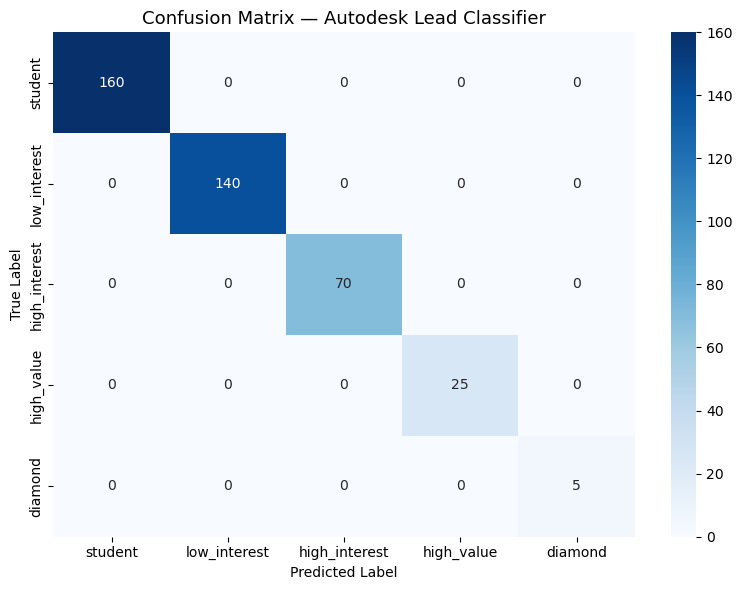

In [14]:
# ─── Evaluate on held-out test set ────────────────────────────────────────────
# Test set was NEVER seen during training — gives us true performance estimate

print("📊 Running evaluation on test set...")
test_results = trainer.evaluate(test_dataset)
print("\nTest Set Metrics:")
for k, v in test_results.items():
    print(f"   {k}: {v:.4f}")

# ─── Full classification report ───────────────────────────────────────────────
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\n📋 Classification Report (per class):")
print(classification_report(
    true_labels, pred_labels,
    target_names=LABELS
))

# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Confusion Matrix — Autodesk Lead Classifier', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 13. 💾 Save the Model

In [15]:
# ─── Save fine-tuned model and tokenizer ──────────────────────────────────────
# The saved model includes only the LoRA adapter weights (small file)
# plus the tokenizer. Base model weights stay on Hugging Face.

SAVE_PATH = './autodesk_lead_classifier_final'

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model saved to: {SAVE_PATH}")
print(f"   To reload: AutoModelForSequenceClassification.from_pretrained('{SAVE_PATH}')")

✅ Model saved to: ./autodesk_lead_classifier_final
   To reload: AutoModelForSequenceClassification.from_pretrained('./autodesk_lead_classifier_final')


## 14. 🔮 Inference on New Incoming Leads

This is the **production prediction pipeline** — the part your inside sales team actually uses.
Given a new raw lead (from Marketo/CRM), classify it into one of the 5 tiers.

In [16]:
# ─── Load the saved model for inference ──────────────────────────────────────

from peft import PeftModel

# Option A: Use the trainer's already-loaded model (quick in same session)
inference_model = model
inference_model.eval()  # Switch to eval mode (disables dropout)

# Option B: Reload from disk (for production deployment in a separate service)
# inference_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
# inference_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
inference_model = inference_model.to(DEVICE)


def predict_lead(lead_dict: dict, top_k: int = 3) -> dict:
    """
    Classify a single incoming lead.
    
    Args:
        lead_dict: Raw lead data (same fields as training data)
        top_k:     Return top-k most likely classes with probabilities
    
    Returns:
        dict with predicted class, confidence, and top-k rankings
    """
    # ── Step 1: Serialize the lead into text (same as training) ───────────────
    row = pd.Series(lead_dict)
    input_text = serialize_lead(row)

    # ── Step 2: Tokenize ──────────────────────────────────────────────────────
    inputs = tokenizer(
        input_text,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ).to(DEVICE)

    # ── Step 3: Forward pass (no gradient needed for inference) ───────────────
    with torch.no_grad():
        outputs = inference_model(**inputs)

    # ── Step 4: Convert logits → probabilities via softmax ────────────────────
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

    # ── Step 5: Rank classes by probability ───────────────────────────────────
    ranked = sorted(zip(LABELS, probs), key=lambda x: x[1], reverse=True)

    return {
        'predicted_class':  ranked[0][0],
        'confidence':       float(ranked[0][1]),
        'top_k_predictions': [
            {'class': cls, 'probability': float(prob)}
            for cls, prob in ranked[:top_k]
        ],
        'input_text': input_text  # For debugging/explainability
    }


print("✅ Inference pipeline ready")

✅ Inference pipeline ready


In [17]:
# ─── Test inference on new leads ──────────────────────────────────────────────
# These are completely new, unseen leads — simulating real incoming CRM data

NEW_LEADS = [
    {
        # ── Expected: diamond ─────────────────────────────────────────────────
        'sales_notes': (
            "CTO at Bechtel contacted us about standardizing on Autodesk BIM stack globally. "
            "They have 15,000 engineers across 40 countries. Multi-year EBA discussion. "
            "Legal and procurement both engaged. ACV estimated at $2M+."
        ),
        'email_opens': 35, 'email_clicks': 22, 'form_fills': 10,
        'webinars_attended': 5, 'site_visits': 55,
        'products_interested': 'BIM 360, Revit, Navisworks, Civil 3D',
        'primary_product': 'BIM 360',
        'requested_demo': 1, 'trial_started': 1,
        'industry': 'Construction', 'company_size': '1000+', 'contact_role': 'CTO'
    },
    {
        # ── Expected: student ─────────────────────────────────────────────────
        'sales_notes': (
            "First-year architecture student at Georgia Tech. Needs AutoCAD for a "
            "studio class. Asked if there's a free or deeply discounted student version. "
            "No professional use case mentioned."
        ),
        'email_opens': 1, 'email_clicks': 0, 'form_fills': 1,
        'webinars_attended': 0, 'site_visits': 2,
        'products_interested': 'AutoCAD',
        'primary_product': 'AutoCAD',
        'requested_demo': 0, 'trial_started': 0,
        'industry': 'Education', 'company_size': '1-10', 'contact_role': 'Student'
    },
    {
        # ── Expected: high_interest ───────────────────────────────────────────
        'sales_notes': (
            "BIM Manager at a mid-size MEP firm evaluating Revit for their team of 30. "
            "Currently using an older competitor. Attended our Revit Migration webinar. "
            "Asked detailed questions about Revit families and interoperability."
        ),
        'email_opens': 14, 'email_clicks': 8, 'form_fills': 4,
        'webinars_attended': 2, 'site_visits': 18,
        'products_interested': 'Revit, BIM 360',
        'primary_product': 'Revit',
        'requested_demo': 1, 'trial_started': 0,
        'industry': 'Engineering', 'company_size': '11-50', 'contact_role': 'BIM Manager'
    }
]

EXPECTED = ['diamond', 'student', 'high_interest']

# ─── Run predictions ──────────────────────────────────────────────────────────
print("═" * 65)
print("🔮  AUTODESK LEAD CLASSIFICATION — INCOMING LEADS")
print("═" * 65)

for i, (lead, expected) in enumerate(zip(NEW_LEADS, EXPECTED)):
    result = predict_lead(lead)
    predicted = result['predicted_class']
    confidence = result['confidence']
    match = '✅' if predicted == expected else '❌'

    print(f"\nLead {i+1}: {lead['contact_role']} @ {lead['industry']} | Expected: {expected}")
    print(f"  {match} Predicted: {predicted.upper():<15} (confidence: {confidence:.1%})")
    print(f"  Top predictions:")
    for p in result['top_k_predictions']:
        bar = '▓' * int(p['probability'] * 20)
        print(f"    {p['class']:>15}: {p['probability']:.1%}  {bar}")

print("\n" + "═" * 65)

═════════════════════════════════════════════════════════════════
🔮  AUTODESK LEAD CLASSIFICATION — INCOMING LEADS
═════════════════════════════════════════════════════════════════

Lead 1: CTO @ Construction | Expected: diamond
  ✅ Predicted: DIAMOND         (confidence: 62.6%)
  Top predictions:
            diamond: 62.6%  ▓▓▓▓▓▓▓▓▓▓▓▓
      high_interest: 18.6%  ▓▓▓
         high_value: 17.7%  ▓▓▓

Lead 2: Student @ Education | Expected: student
  ✅ Predicted: STUDENT         (confidence: 99.9%)
  Top predictions:
            student: 99.9%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
         high_value: 0.0%  
       low_interest: 0.0%  

Lead 3: BIM Manager @ Engineering | Expected: high_interest
  ✅ Predicted: HIGH_INTEREST   (confidence: 98.9%)
  Top predictions:
      high_interest: 98.9%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
            diamond: 1.0%  
         high_value: 0.1%  

═════════════════════════════════════════════════════════════════


## 15. 🏭 Batch Inference — Score Many Leads at Once

For production use, score a batch of CRM leads efficiently.

In [18]:
# ─── Batch prediction for production scoring ──────────────────────────────────

def predict_leads_batch(leads_list: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score a large batch of leads efficiently.
    
    Args:
        leads_list: List of lead dicts (from CRM/Marketo export)
        batch_size: Number of leads to process at once
    
    Returns:
        DataFrame with predicted_class, confidence, and all class probabilities
    """
    results = []

    for i in range(0, len(leads_list), batch_size):
        batch = leads_list[i : i + batch_size]

        # Serialize all leads in the batch
        texts = [serialize_lead(pd.Series(lead)) for lead in batch]

        # Tokenize the batch
        inputs = tokenizer(
            texts,
            return_tensors='pt',
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH
        ).to(DEVICE)

        # Forward pass
        with torch.no_grad():
            outputs = inference_model(**inputs)

        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

        for lead, prob_row in zip(batch, probs):
            pred_idx = np.argmax(prob_row)
            row = {
                'contact_role':     lead.get('contact_role', 'Unknown'),
                'industry':         lead.get('industry', 'Unknown'),
                'predicted_class':  ID2LABEL[pred_idx],
                'confidence':       float(prob_row[pred_idx]),
            }
            # Add probability for each class
            for label, prob in zip(LABELS, prob_row):
                row[f'prob_{label}'] = float(prob)
            results.append(row)

    return pd.DataFrame(results)


# ── Run batch prediction on 20 synthetic new leads ───────────────────────────
new_batch = [generate_lead(random.choice(LABELS)) for _ in range(20)]
scores_df = predict_leads_batch(new_batch)

print("📋 Batch Scoring Results (20 new leads):")
display_cols = ['contact_role', 'industry', 'predicted_class', 'confidence']
print(scores_df[display_cols].to_string(index=False))

print(f"\n📊 Predicted class distribution:")
print(scores_df['predicted_class'].value_counts())

📋 Batch Scoring Results (20 new leads):
       contact_role              industry predicted_class  confidence
            Student Media & Entertainment         student    0.999788
Procurement Manager         Manufacturing         diamond    0.897004
         IT Manager           Engineering      high_value    0.998041
        BIM Manager          Construction      high_value    0.997853
          Architect Media & Entertainment   high_interest    0.998652
           Engineer            Automotive    low_interest    0.999712
            Student Media & Entertainment         student    0.999697
           Engineer          Architecture   high_interest    0.998899
     VP Engineering          Construction      high_value    0.997563
     VP Engineering         Manufacturing         diamond    0.824359
        BIM Manager         Manufacturing      high_value    0.998968
        BIM Manager Media & Entertainment      high_value    0.999015
         Freelancer          Architecture    low_i

## 16. 🗺️ Summary & Production Checklist

### What we built
| Step | What | Why |
|------|------|-----|
| Serialization | Text + tabular → single string | LLM processes everything as language |
| LoRA | Inject small trainable matrices | Train only 1-3% of params; fast & cheap |
| QLoRA | 4-bit quantization | Run 7B model on 1 GPU |
| Weighted sampling | Rare classes picked more often | Model sees diamond leads regularly |
| Weighted loss | Wrong diamond prediction costs more | Forces learning of rare classes |
| Macro F1 | Evaluation metric | Treats all classes equally, not just accuracy |

### Moving to Production
- [ ] Replace `distilbert-base-uncased` with `mistralai/Mistral-7B-v0.1` for better accuracy
- [ ] Connect real Marketo API + CRM data instead of synthetic data
- [ ] Add W&B / MLflow experiment tracking (`report_to='wandb'`)
- [ ] Set up model serving endpoint (FastAPI, Sagemaker, or Hugging Face Inference)
- [ ] Monitor per-class F1 in production — class drift is common in sales data
- [ ] Re-evaluate label definitions with sales team to avoid label leakage